## Monkey_936 （dataID:251637) fMOST data_analysis 

<img src="../figures/injection_info.png" alt="injection_info" style="max-width: 85%; max-height: 65vh; height: auto; object-fit: contain; margin: 10px auto;">

<img src="../figures/phase1_analysis_begin.png" alt="plan" style="max-width: 85%; max-height: 65vh; height: auto; object-fit: contain; margin: 10px auto;">




In [1]:
import neuro_tracer as nt
import region_analysis as ra


import sys,copy,os,inspect
import numpy as np
import pandas as pd

neurovis_path = os.path.abspath(r'D:\projectome_analysis\neuron-vis\neuronVis')
sys.path.append(neurovis_path)

import IONData 
iondata = IONData.IONData()
import nibabel as nib
import nrrd



## Region analysis

### Atlas is ARM, onto NMT v2.1.
 The advantage over v2.0 is that it differentiate LR hemispheres.

<img src="../figures/atlas.png" alt="arm" style="max-width: 85%; max-height: 65vh; height: auto; object-fit: contain; margin: 10px auto;">

### RA's Neurontype classifier

<img src="../figures/clf_workflow.png" alt="classifier workflow" style="max-width: 85%; max-height: 65vh; height: auto; object-fit: contain; margin: 10px auto;">

In [2]:
# %%capture

atlas_path = r'D:\projectome_analysis\atlas\ARM_in_NMT_v2.1_sym.nii.gz'
table_path = r'D:\projectome_analysis\atlas\ARM_key_all.txt'
template_path = r"D:\projectome_analysis\atlas\NMT_v2.1_sym\NMT_v2.1_sym\NMT_v2.1_sym_SS.nii.gz"

atlas_nii = nib.load(atlas_path)
atlas_data = atlas_nii.get_fdata()
global_id_df = pd.read_csv(table_path, delimiter='\t')

template_nii = nib.load(template_path)
reso = np.diag(atlas_nii.affine) [0:3]
print(f'Atlas dimension {atlas_nii.shape}, Voxel reso: {reso} mm \n \n ')

all_neuron_ra = ra.PopulationRegionAnalysis('251637', atlas_data, global_id_df,template_img=template_nii,nii_space='monkey')
all_neuron_ra.process(limit = None, level=6)  


Atlas dimension (256, 312, 200, 1, 6), Voxel reso: [0.25 0.25 0.25] mm 
 
 
Processing 562 neurons at Level 6...
  -> 001.swc
Loading SWC from local file: d:\projectome_analysis\main_scripts\processed_neurons\251637\001.swc
there are 204 terminal nodes

Constructing branches, assigning orders 
 


Finished with 401 branches
  -> 002.swc
Loading SWC from local file: d:\projectome_analysis\main_scripts\processed_neurons\251637\002.swc
there are 24 terminal nodes

Constructing branches, assigning orders 
 


Finished with 42 branches
  -> 003.swc
Loading SWC from local file: d:\projectome_analysis\main_scripts\processed_neurons\251637\003.swc
there are 46 terminal nodes

Constructing branches, assigning orders 
 


Finished with 83 branches
  -> 004.swc
Loading SWC from local file: d:\projectome_analysis\main_scripts\processed_neurons\251637\004.swc
there are 222 terminal nodes

Constructing branches, assigning orders 
 


Finished with 438 branches
  -> 005.swc
Loading SWC from local fil

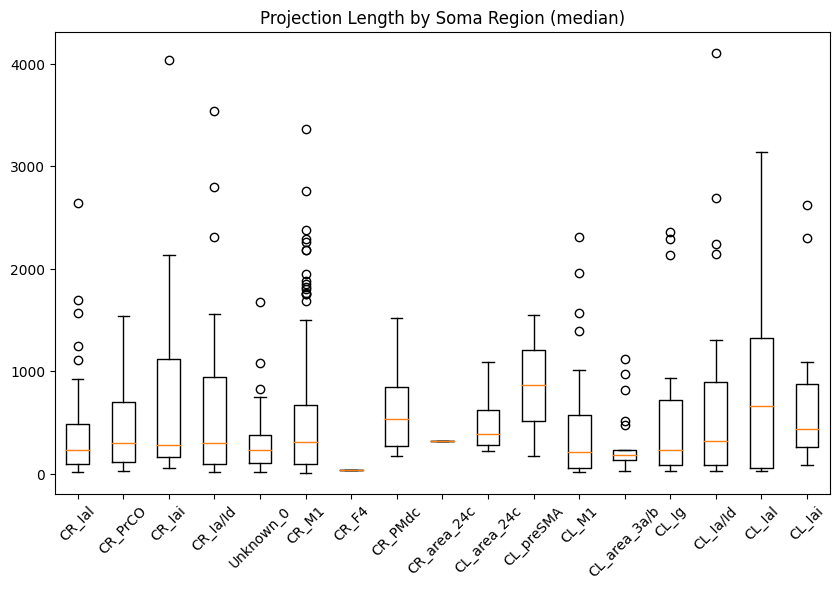

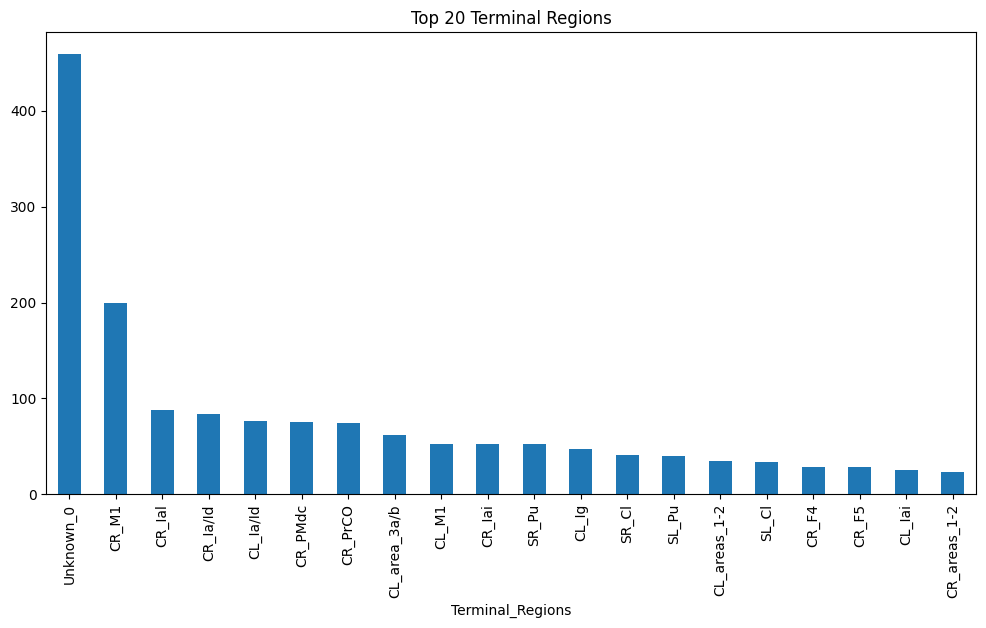

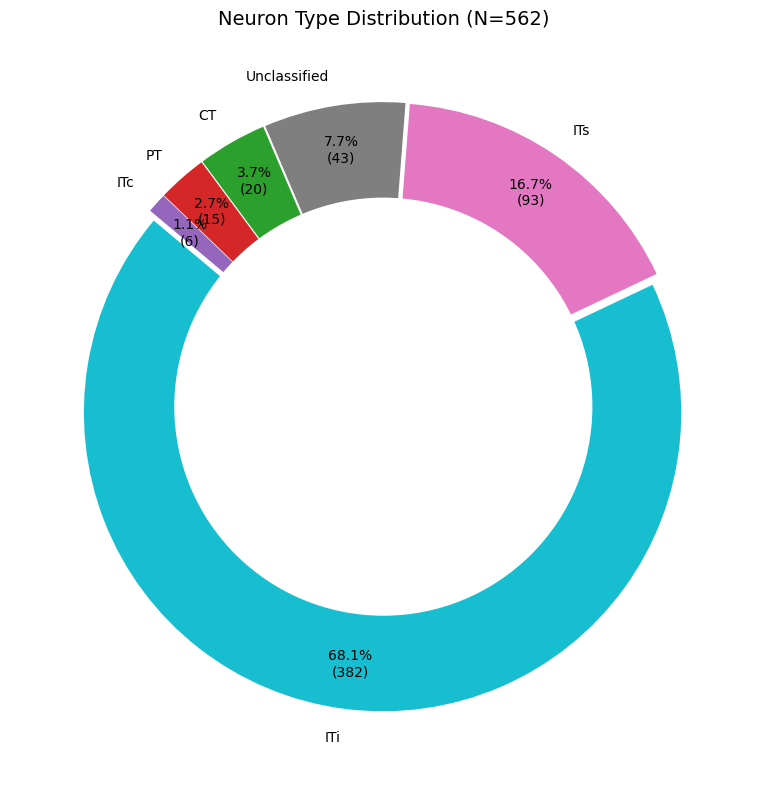

,NeuronID,Neuron_Type,CR_Ial,SR_Cl,SR_Pu,SR_IPAC,SR_ac,SR_Acb,SR_VP,CR_PrCO,...,SL_BM,CL_mid_ERh,CL_area_35,SL_IPAC,CL_area_10mc,CL_area_14r,CL_RTM,SL_LaV,SL_MM,CL_PGa
0,001.swc,ITs,329.489,14.371,226.388,8.567,90.096,2.917,0.610,21.657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,002.swc,ITi,23.567,0.000,0.000,0.000,0.000,0.000,0.000,2.182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,003.swc,ITi,18.999,0.000,0.000,0.000,0.000,0.000,0.000,46.194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,004.swc,ITs,18.040,55.415,937.607,1.746,152.903,18.748,0.000,58.495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,005.swc,PT,8.899,8.036,8.348,0.000,28.746,2.066,14.471,47.029,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,558.swc,ITi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
558,559.swc,ITi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
559,560.swc,ITi,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,561.swc,ITi,0.000,20.984,9.373,0.000,0.000,0.000,0.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
%matplotlib inline    

all_neuron_ra.plot_projection_by_soma(stat='median')  # or 'mean'
all_neuron_ra.plot_terminal_distribution()
all_neuron_ra.plot_type_distribution()
all_neuron_ra.get_region_matrix()



In [ ]:
# region_matrix=pop.get_region_matrix()
# region_matrix.to_csv('936_region_matrix.csv')


## INS table and ACC table

In [4]:

insula_abbr_table =global_id_df['Abbreviation'][global_id_df['Full_Name'].str.contains('insula',case=False)]
cingulate_abbr_table =global_id_df['Abbreviation'][global_id_df['Full_Name'].str.contains('|'.join(['cingulate','23','24']),case=False)]
print('there are %d insula regions in the monkey 936 atlas'%len(insula_abbr_table),'\n',insula_abbr_table.head(5),'\n')
print('there are %d cingulate regions in the monkey 936 atlas'%len(cingulate_abbr_table),  '\n', cingulate_abbr_table.head(5))

there are 22 insula regions in the monkey 936 atlas 
 38    CL_Iam/Iapm
39      CL_lat_Ia
40         CL_Iai
41         CL_Ial
42        CL_Iapl
Name: Abbreviation, dtype: object 

there are 38 cingulate regions in the monkey 936 atlas 
 1          CL_ACgG
2           CL_ACC
5       CL_area_24
6    CL_area_24a/b
7      CL_area_24a
Name: Abbreviation, dtype: object


In [ ]:
import matplotlib.pyplot as plt
neuron_analysis_df = all_neuron_ra.plot_dataframe

INS_df = neuron_analysis_df[neuron_analysis_df['Soma_Region'].isin(insula_abbr_table.tolist())]
ACC_df = neuron_analysis_df[neuron_analysis_df['Soma_Region'].isin(cingulate_abbr_table.tolist())]

# Import region_analysis plotting functions
from region_analysis import plot_soma_distribution_df, plot_type_distribution_df, plot_terminal_distribution_df

print(f'there are {len(INS_df)} insula neurons and {len(ACC_df)} cingulate neurons')

# Plot using region_analysis standalone functions
if not INS_df.empty:
    print("\n=== Insula Neurons ===")
    plot_soma_distribution_df(INS_df, title='Insula Neurons - Soma Distribution')
    plot_type_distribution_df(INS_df, title='Insula Neurons - Type Distribution')
    plot_terminal_distribution_df(INS_df, top_n=20, title='Insula Neurons - Top 20 Terminal Regions')

if not ACC_df.empty:
    print("\n=== Cingulate (ACC) Neurons ===")
    plot_soma_distribution_df(ACC_df, title='ACC Neurons - Soma Distribution')
    plot_type_distribution_df(ACC_df, title='ACC Neurons - Type Distribution')
    plot_terminal_distribution_df(ACC_df, top_n=20, title='ACC Neurons - Top 20 Terminal Regions')


NameError: name 'all_neuron_ra' is not defined

In [7]:
# Export to Excel files (v2 format with all columns)
import os
directory = 'neuron_tables'
if not os.path.exists(directory):
    os.makedirs(directory)
# Export to Excel files (v2 format with all columns)
if not ACC_df.empty:
    filename = 'ACC_df_v3.xlsx'
    ACC_df.to_excel('neuron_tables/ACC_df_v3.xlsx', index=False)
    print(f"Exported ACC_df with {len(ACC_df)} neurons to {filename}")

if not INS_df.empty:
    filename = 'INS_df_v3.xlsx'
    INS_df.to_excel('neuron_tables/INS_df_v3.xlsx', index=False)
    print(f"Exported INS_df with {len(INS_df)} neurons to {filename}")

print("\nTables exported successfully!")

Exported ACC_df with 5 neurons to ACC_df_v3.xlsx
Exported INS_df with 212 neurons to INS_df_v3.xlsx

Tables exported successfully!


## Load Processed Dataframes Directly

If you have already exported ACC_df and INS_df, you can load them directly without re-running the full analysis.

Loaded 212 insula neurons
Loaded 5 cingulate neurons

Terminal_Regions type check: <class 'list'>

=== Insula Neurons ===


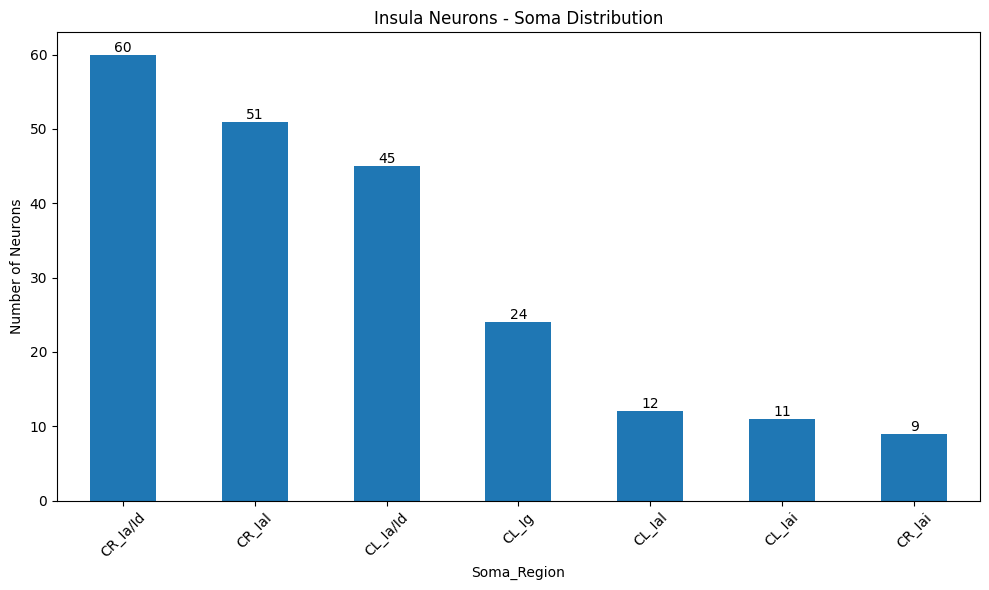

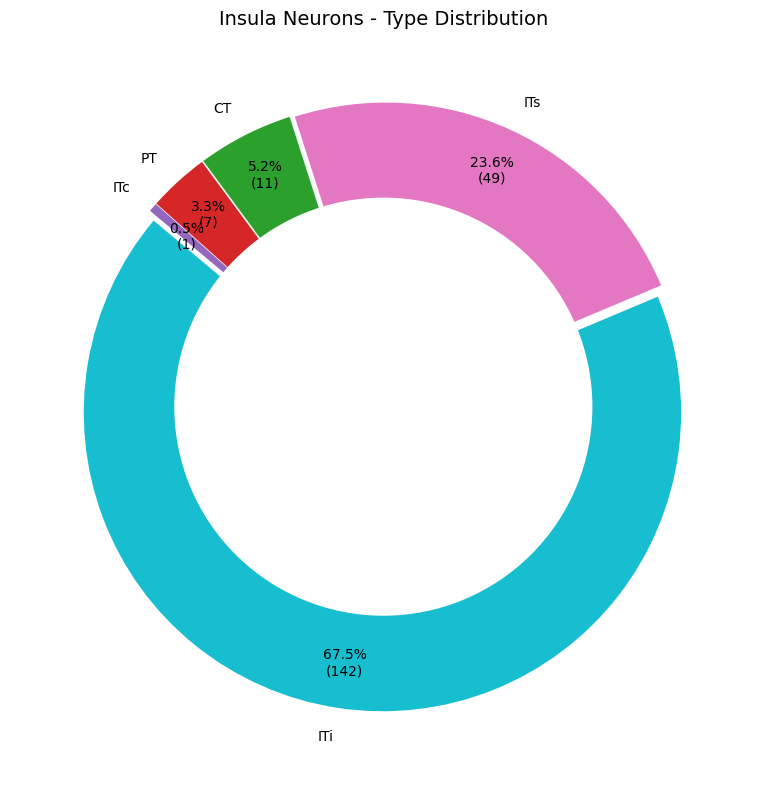

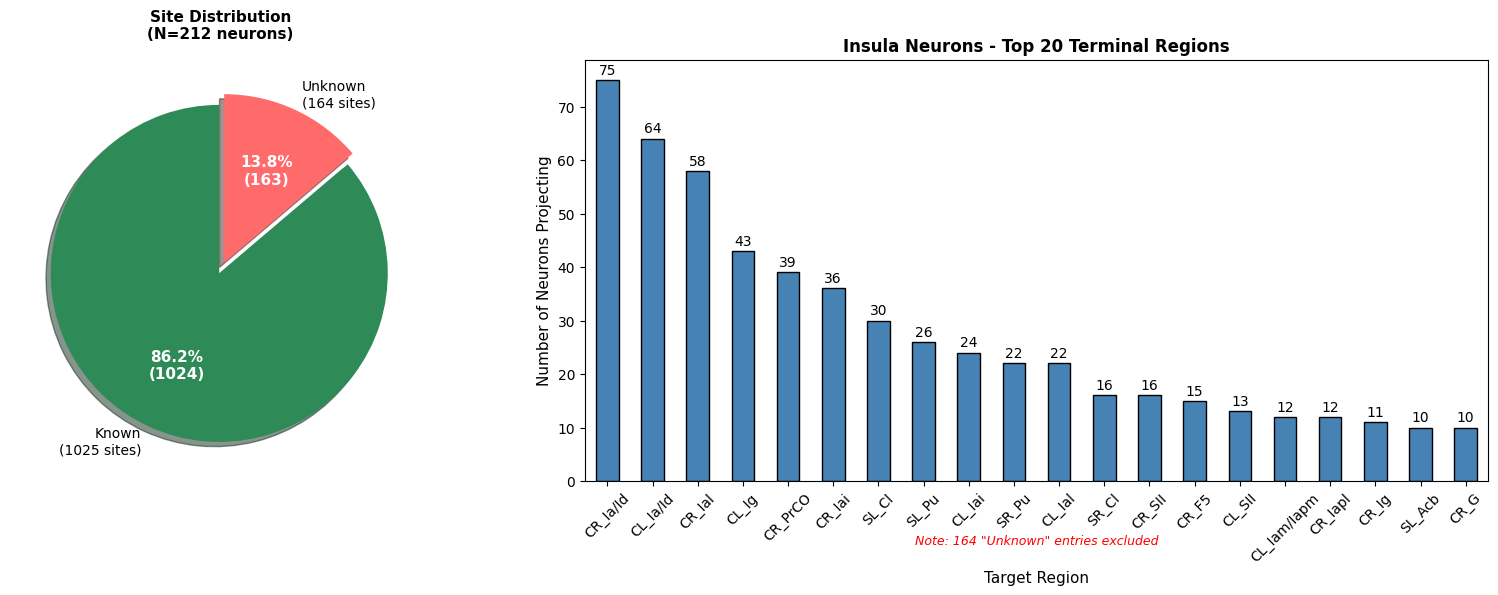

TERMINAL REGION DISTRIBUTION REPORT

--- Known vs Unknown Statistics ---
  Total projection sites: 1189
  Known sites: 1025 (86.2%)
  Unknown sites: 164 (13.8%)
  Neurons with unknown regions: 164 (77.4%)
  Neurons with only known regions: 48 (22.6%)

--- Terminal Region Distribution ---
  Total unique regions shown: 20
  Total projection entries (after filtering): 554
  Unknown entries excluded from plot: 164

  Top 20 regions:
     1. CR_Ia/Id: 75 neurons (13.5%)
     2. CL_Ia/Id: 64 neurons (11.6%)
     3. CR_Ial: 58 neurons (10.5%)
     4. CL_Ig: 43 neurons (7.8%)
     5. CR_PrCO: 39 neurons (7.0%)
     6. CR_Iai: 36 neurons (6.5%)
     7. SL_Cl: 30 neurons (5.4%)
     8. SL_Pu: 26 neurons (4.7%)
     9. CL_Iai: 24 neurons (4.3%)
    10. SR_Pu: 22 neurons (4.0%)
    11. CL_Ial: 22 neurons (4.0%)
    12. SR_Cl: 16 neurons (2.9%)
    13. CR_SII: 16 neurons (2.9%)
    14. CR_F5: 15 neurons (2.7%)
    15. CL_SII: 13 neurons (2.3%)
    16. CL_Iam/Iapm: 12 neurons (2.2%)
    17. CR_Iapl:

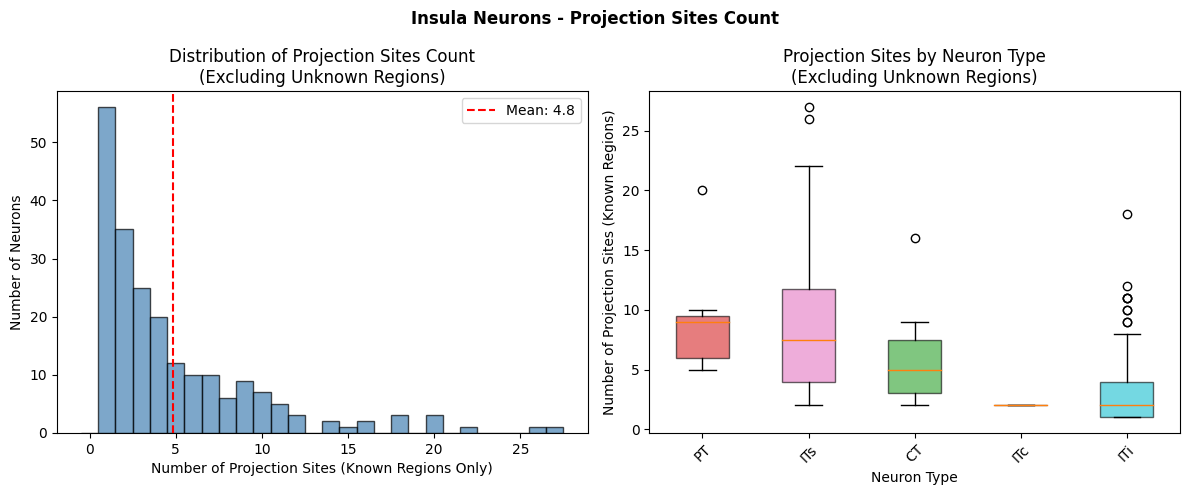

PROJECTION SITES STATISTICS (KNOWN REGIONS ONLY)

Total neurons analyzed: 212

--- Known Projection Sites (Excluding Unknown) ---
  Total known sites: 1025
  Mean known sites per neuron: 4.83
  Median: 3.0
  Min: 1
  Max: 27
  Std: 4.86

  Distribution of known sites per neuron:
    1 site(s): 56 neurons (26.4%)
    2 site(s): 35 neurons (16.5%)
    3 site(s): 25 neurons (11.8%)
    4 site(s): 20 neurons (9.4%)
    5 site(s): 12 neurons (5.7%)
    6 site(s): 10 neurons (4.7%)
    7 site(s): 10 neurons (4.7%)
    8 site(s): 6 neurons (2.8%)
    9 site(s): 9 neurons (4.2%)
    10 site(s): 7 neurons (3.3%)

--- Unknown Projection Sites (Excluded from Plot) ---
  Neurons with unknown sites: 164 (77.4%)
  Total unknown sites excluded: 164
  Mean unknown sites per neuron: 0.77

--- Outlier Statistics ---
  Neurons with outliers: 164 (77.4%)
  Total outliers: 5283
  Mean outliers per neuron: 24.92

  Distribution of outlier count per neuron:
    0 outliers: 48 neurons (22.6%)
    1 outlier(s)

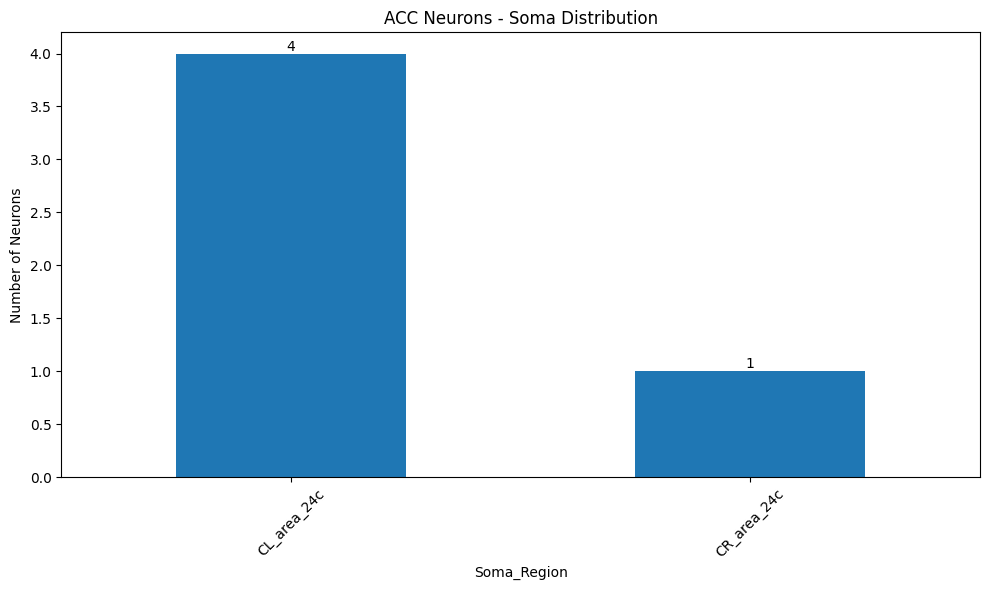

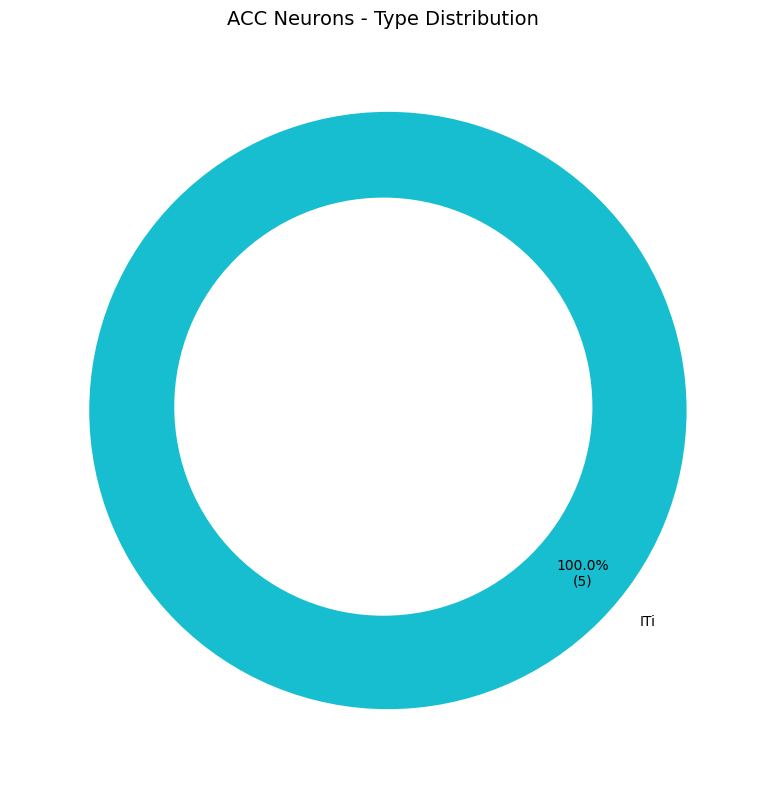

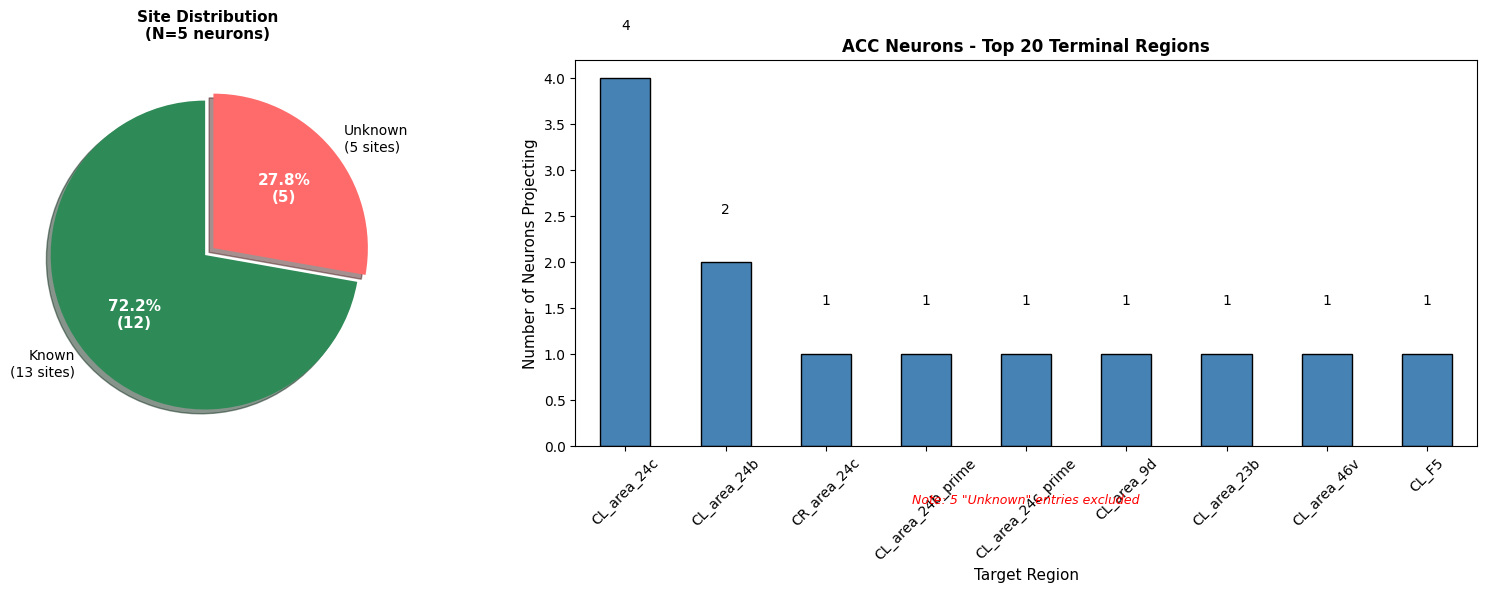

TERMINAL REGION DISTRIBUTION REPORT

--- Known vs Unknown Statistics ---
  Total projection sites: 18
  Known sites: 13 (72.2%)
  Unknown sites: 5 (27.8%)
  Neurons with unknown regions: 5 (100.0%)
  Neurons with only known regions: 0 (0.0%)

--- Terminal Region Distribution ---
  Total unique regions shown: 9
  Total projection entries (after filtering): 13
  Unknown entries excluded from plot: 5

  Top 9 regions:
     1. CL_area_24c: 4 neurons (30.8%)
     2. CL_area_24b: 2 neurons (15.4%)
     3. CR_area_24c: 1 neurons (7.7%)
     4. CL_area_24b_prime: 1 neurons (7.7%)
     5. CL_area_24c_prime: 1 neurons (7.7%)
     6. CL_area_9d: 1 neurons (7.7%)
     7. CL_area_23b: 1 neurons (7.7%)
     8. CL_area_46v: 1 neurons (7.7%)
     9. CL_F5: 1 neurons (7.7%)


[Report saved to: neuron_tables/ACC_terminal_distribution_report.txt]


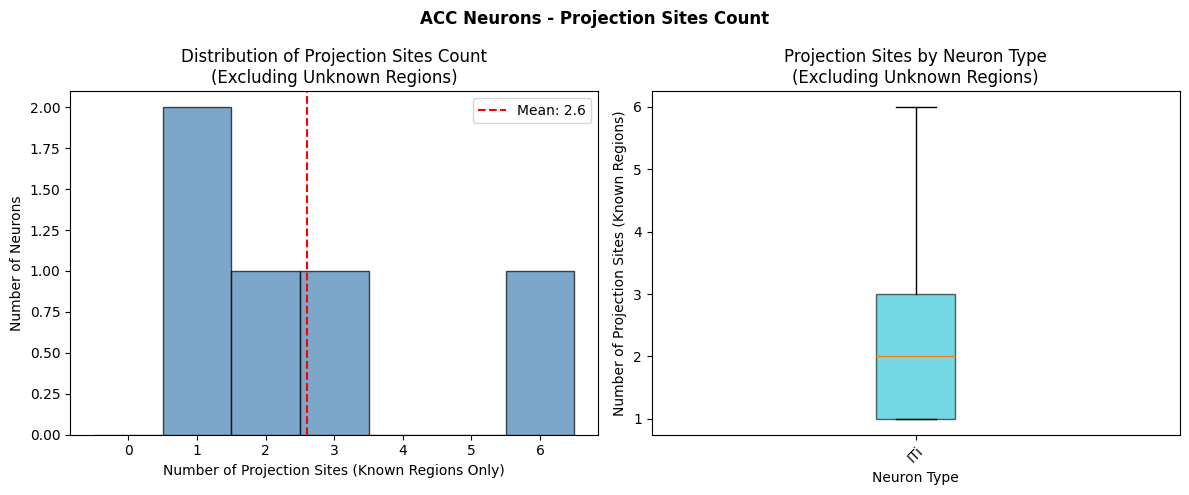

PROJECTION SITES STATISTICS (KNOWN REGIONS ONLY)

Total neurons analyzed: 5

--- Known Projection Sites (Excluding Unknown) ---
  Total known sites: 13
  Mean known sites per neuron: 2.60
  Median: 2.0
  Min: 1
  Max: 6
  Std: 2.07

  Distribution of known sites per neuron:
    1 site(s): 2 neurons (40.0%)
    2 site(s): 1 neurons (20.0%)
    3 site(s): 1 neurons (20.0%)
    6 site(s): 1 neurons (20.0%)

--- Unknown Projection Sites (Excluded from Plot) ---
  Neurons with unknown sites: 5 (100.0%)
  Total unknown sites excluded: 5
  Mean unknown sites per neuron: 1.00

--- Outlier Statistics ---
  Neurons with outliers: 5 (100.0%)
  Total outliers: 342
  Mean outliers per neuron: 68.40

  Distribution of outlier count per neuron:
    3 outlier(s): 1 neurons (20.0%)
    40 outlier(s): 1 neurons (20.0%)
    59 outlier(s): 1 neurons (20.0%)
    96 outlier(s): 1 neurons (20.0%)
    144 outlier(s): 1 neurons (20.0%)


[Report saved to: neuron_tables/ACC_projection_sites_report.txt]


In [3]:
%matplotlib inline
# Load processed dataframes directly without full analysis
import pandas as pd
import os
from region_analysis import (
    plot_soma_distribution_df, 
    plot_type_distribution_df, 
    plot_terminal_distribution_df,
    plot_projection_sites_count_df,
    load_processed_df
)

# Load from files using load_processed_df which properly parses Terminal_Regions as list

INS_df = load_processed_df('neuron_tables/INS_df_v3.xlsx')
ACC_df = load_processed_df('neuron_tables/ACC_df_v3.xlsx')

print(f"Loaded {len(INS_df)} insula neurons")
print(f"Loaded {len(ACC_df)} cingulate neurons")

# Verify Terminal_Regions is properly parsed as list
print(f"\nTerminal_Regions type check: {type(INS_df['Terminal_Regions'].iloc[0])}")

# Create reports directory
reports_dir = 'neuron_tables'
if not os.path.exists(reports_dir):
    os.makedirs(reports_dir)

# Plot and save reports for INS_df
if not INS_df.empty:
    print("\n=== Insula Neurons ===")
    plot_soma_distribution_df(INS_df, title='Insula Neurons - Soma Distribution')
    plot_type_distribution_df(INS_df, title='Insula Neurons - Type Distribution')
    
    # Save terminal distribution report
    terminal_report = plot_terminal_distribution_df(
        INS_df, 
        top_n=20, 
        title='Insula Neurons - Top 20 Terminal Regions',
        save_report_path=f'{reports_dir}/INS_terminal_distribution_report.txt'
    )
    
    # Save projection sites report
    sites_report = plot_projection_sites_count_df(
        INS_df,
        title='Insula Neurons - Projection Sites Count',
        save_report_path=f'{reports_dir}/INS_projection_sites_report.txt'
    )

# Plot and save reports for ACC_df
if not ACC_df.empty:
    print("\n=== Cingulate (ACC) Neurons ===")
    plot_soma_distribution_df(ACC_df, title='ACC Neurons - Soma Distribution')
    plot_type_distribution_df(ACC_df, title='ACC Neurons - Type Distribution')
    
    # Save terminal distribution report
    terminal_report = plot_terminal_distribution_df(
        ACC_df, 
        top_n=20, 
        title='ACC Neurons - Top 20 Terminal Regions',
        save_report_path=f'{reports_dir}/ACC_terminal_distribution_report.txt'
    )
    
    # Save projection sites report
    sites_report = plot_projection_sites_count_df(
        ACC_df,
        title='ACC Neurons - Projection Sites Count',
        save_report_path=f'{reports_dir}/ACC_projection_sites_report.txt'
    )

In [ ]:
from region_analysis import plot_soma_distribution_df, plot_type_distribution_df, plot_terminal_distribution_df, plot_projection_sites_count_df
import os

# Create reports directory
reports_dir = 'analysis_reports'
if not os.path.exists(reports_dir):
    os.makedirs(reports_dir)

# Plot and save reports for INS_df
if not INS_df.empty:
    print("\n=== Insula Neurons ===")
    plot_soma_distribution_df(INS_df, title='Insula Neurons - Soma Distribution')
    plot_type_distribution_df(INS_df, title='Insula Neurons - Type Distribution')
    
    # Save terminal distribution report
    terminal_report = plot_terminal_distribution_df(
        INS_df, 
        top_n=20, 
        title='Insula Neurons - Top 20 Terminal Regions',
        save_report_path=f'{reports_dir}/INS_terminal_distribution_report.txt'
    )
    
    # Save projection sites report
    sites_report = plot_projection_sites_count_df(
        INS_df,
        title='Insula Neurons - Projection Sites Count',
        save_report_path=f'{reports_dir}/INS_projection_sites_report.txt'
    )

# Plot and save reports for ACC_df
if not ACC_df.empty:
    print("\n=== Cingulate (ACC) Neurons ===")
    plot_soma_distribution_df(ACC_df, title='ACC Neurons - Soma Distribution')
    plot_type_distribution_df(ACC_df, title='ACC Neurons - Type Distribution')
    
    # Save terminal distribution report
    terminal_report = plot_terminal_distribution_df(
        ACC_df, 
        top_n=20, 
        title='ACC Neurons - Top 20 Terminal Regions',
        save_report_path=f'{reports_dir}/ACC_terminal_distribution_report.txt'
    )
    
    # Save projection sites report
    sites_report = plot_projection_sites_count_df(
        ACC_df,
        title='ACC Neurons - Projection Sites Count',
        save_report_path=f'{reports_dir}/ACC_projection_sites_report.txt'
    )